# Lesson 2 - Exercise 1: Quantifying KV Cache Memory Growth

**Goal:** Empirically measure and analyze the growth in peak GPU memory consumption during LLM inference as the number of generated tokens increases, thereby quantifying the memory footprint of the Key-Value (KV) Cache.

## 2. Imports and Configuration

In [1]:
import os
import torch
import time
from transformers import AutoModelForCausalLM, AutoTokenizer
import gc # For garbage collection
import matplotlib.pyplot as plt

# --- Configuration ---
# The Udacity workspace ships a local copy of Llama-3.2-1B; elsewhere we fall back to the
# ungated Hub mirror of the same weights (override with the UDACI_MODEL env var).
_local_llama = "/voc/shared/models/llama/Llama-3.2-1B"
model_name = os.environ.get("UDACI_MODEL", _local_llama if os.path.isdir(_local_llama) else "unsloth/Llama-3.2-1B")
if os.path.isdir(model_name):
    os.environ["HF_HUB_OFFLINE"] = "1"

device = "cuda" if torch.cuda.is_available() else "cpu"
if device == "cpu":
    print("WARNING: This exercise requires a CUDA-enabled GPU for meaningful memory measurements. "
          "On CPU we instead measure the exact size of the returned KV-cache tensors.")

# Determine appropriate dtype: bf16 if the GPU supports it, else fp16 on GPU, fp32 on CPU
if device == "cuda":
    if torch.cuda.is_bf16_supported():
        dtype = torch.bfloat16
        print("Using torch.bfloat16")
    else:
        dtype = torch.float16
        print("Using torch.float16 (bf16 not supported)")
else:
    dtype = torch.float32 # Default for CPU
    print("Using torch.float32 for CPU")

prompt = "The best way to optimize LLM inference is"

# Different max_new_tokens values to test (spread out enough to see a trend)
generation_lengths = [10, 50, 100, 200, 400]

print(f"Device: {device}")
print(f"Model: {model_name}")
print(f"Prompt: '{prompt}'")
print(f"Generation lengths to test: {generation_lengths}")


Using torch.float32 for CPU
Device: cpu
Model: unsloth/Llama-3.2-1B
Prompt: 'The best way to optimize LLM inference is'
Generation lengths to test: [10, 50, 100, 200, 400]


## 3. Helper Function to Measure Peak Memory

In [2]:
def get_peak_gpu_memory_mb(device_to_check="cuda"):
    """Records the peak GPU memory allocated since the last reset for the specified device."""
    if torch.cuda.is_available() and device_to_check == "cuda":
        torch.cuda.synchronize() # Ensure all CUDA operations are complete
        # Peak memory held by tensors since the last torch.cuda.reset_peak_memory_stats()
        peak_mem_bytes = torch.cuda.max_memory_allocated(device_to_check)
        return peak_mem_bytes / (1024 * 1024) # Convert to MB
    return 0 # Return 0 if not on CUDA or for CPU


def get_kv_cache_size_mb(past_key_values):
    """Exact number of bytes held by the KV cache returned by generate() (works on CPU and GPU).

    Handles both the legacy tuple-of-tuples layout and the transformers `Cache` object.
    """
    total = 0
    if past_key_values is None:
        return 0.0
    if hasattr(past_key_values, "layers"):          # transformers >= 4.5x DynamicCache
        for layer in past_key_values.layers:
            for name in ("keys", "values"):
                t = getattr(layer, name, None)
                if isinstance(t, torch.Tensor):
                    total += t.numel() * t.element_size()
    elif hasattr(past_key_values, "key_cache"):     # older DynamicCache
        for t in list(past_key_values.key_cache) + list(past_key_values.value_cache):
            total += t.numel() * t.element_size()
    else:                                           # legacy tuple layout
        for layer in past_key_values:
            for t in layer:
                total += t.numel() * t.element_size()
    return total / (1024 * 1024)


## 4. Load Model and Tokenizer

In [3]:
print(f"\nLoading model and tokenizer for {model_name}...")
try:
    # Load the tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_name)

    # Llama has no pad token by default; reuse EOS so generate() does not complain
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token

    # Load the model in the chosen dtype with the PyTorch SDPA attention kernel and move it to the device
    model = AutoModelForCausalLM.from_pretrained(model_name, dtype=dtype, attn_implementation="sdpa").to(device)

    # Evaluation mode (no dropout, no grad bookkeeping)
    model.eval()

    print("Model and tokenizer loaded successfully.")
except Exception as e:
    print(f"Error loading model/tokenizer: {e}")
    model = None



Loading model and tokenizer for unsloth/Llama-3.2-1B...


Loading weights:   0%|          | 0/146 [00:00<?, ?it/s]

Model and tokenizer loaded successfully.


## 5. Test Configuration & Measurement Loop

In [4]:
peak_memory_results_mb = []      # on CUDA: peak allocated MB during generate(); on CPU: exact KV-cache MB
actual_tokens_generated_list = []
generation_times = []
initial_peak_memory_mb = 0.0

print("\n--- Measuring KV Cache Memory Growth ---")

if model is not None:
    if device == "cuda":
        # Initial memory measurement (model loaded, no generation yet)
        torch.cuda.reset_peak_memory_stats(device) # Reset before taking baseline
        _ = model(torch.tensor([[0]], device=device)) # Dummy forward pass to ensure model is fully on GPU
        torch.cuda.synchronize(device)
        initial_peak_memory_mb = get_peak_gpu_memory_mb(device)
        print(f"Initial peak memory (model loaded on GPU): {initial_peak_memory_mb:.2f} MB")
    else:
        print("CPU run: reporting the exact size of the KV-cache tensors returned by generate() instead of CUDA peak memory.")

    for length in generation_lengths:
        print(f"\nGenerating {length} new tokens...")

        # Tokenize the prompt and move tensors to the device
        inputs = tokenizer(prompt, return_tensors="pt").to(device)

        if inputs is None:
            print("  Skipping due to uninitialized inputs.")
            peak_memory_results_mb.append(float('nan'))
            actual_tokens_generated_list.append(0)
            generation_times.append(float('nan'))
            continue

        # Reset GPU memory stats before this specific generation run
        if device == "cuda":
            torch.cuda.reset_peak_memory_stats(device)

        start_time = time.perf_counter()
        with torch.no_grad():
            try:
                # Generate tokens with the KV cache enabled; return_dict_in_generate lets us
                # inspect the cache object afterwards.
                outputs = model.generate(
                    inputs["input_ids"],
                    attention_mask=inputs["attention_mask"],
                    max_new_tokens=length,
                    min_new_tokens=length,      # force the full length so the trend is clean
                    do_sample=False,
                    use_cache=True,
                    pad_token_id=tokenizer.pad_token_id,
                    return_dict_in_generate=True,
                )

                if outputs is None:
                    raise ValueError("Outputs from model.generate() is None.")

                # Calculate actual number of new tokens generated
                num_input_tokens = inputs["input_ids"].shape[1]   # tokens in the input prompt
                num_output_tokens = outputs.sequences.shape[1]    # tokens in the output (prompt + new)
                actual_new_tokens = num_output_tokens - num_input_tokens
                actual_tokens_generated_list.append(actual_new_tokens)

            except Exception as e:
                print(f"  Error during generation for length {length}: {e}")
                peak_memory_results_mb.append(float('nan'))
                actual_tokens_generated_list.append(0)
                generation_times.append(float('nan'))
                continue

        # Synchronize CUDA operations before recording memory and time
        if device == "cuda":
            torch.cuda.synchronize(device)
        end_time = time.perf_counter()
        gen_time = end_time - start_time
        generation_times.append(gen_time)

        # Record peak GPU memory allocated during THIS generation run (CPU: exact KV-cache bytes)
        if device == "cuda":
            current_peak_memory_mb = get_peak_gpu_memory_mb(device)
        else:
            current_peak_memory_mb = get_kv_cache_size_mb(getattr(outputs, "past_key_values", None))
        peak_memory_results_mb.append(current_peak_memory_mb)

        print(f"  Actual new tokens generated: {actual_new_tokens}")
        print(f"  Peak memory allocated for this generation: {current_peak_memory_mb:.2f} MB")
        print(f"  Generation time: {gen_time:.4f} seconds")

        # Cleanup
        del outputs
        del inputs
        if device == "cuda":
            torch.cuda.empty_cache()
        gc.collect()
else:
    print("Skipping measurement loop: Model not loaded.")


[transformers] Both `max_new_tokens` (=10) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



--- Measuring KV Cache Memory Growth ---
CPU run: reporting the exact size of the KV-cache tensors returned by generate() instead of CUDA peak memory.

Generating 10 new tokens...


[transformers] Both `max_new_tokens` (=50) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Actual new tokens generated: 10
  Peak memory allocated for this generation: 1.19 MB
  Generation time: 2.8006 seconds

Generating 50 new tokens...


[transformers] Both `max_new_tokens` (=100) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


...

[transformers] Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Actual new tokens generated: 100
  Peak memory allocated for this generation: 6.81 MB
  Generation time: 25.5450 seconds

Generating 200 new tokens...


[transformers] Both `max_new_tokens` (=400) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Actual new tokens generated: 200
  Peak memory allocated for this generation: 13.06 MB
  Generation time: 51.0215 seconds

Generating 400 new tokens...


  Actual new tokens generated: 400
  Peak memory allocated for this generation: 25.56 MB
  Generation time: 102.8233 seconds


## 6. Deliverables: Analysis and Reporting


--- Results Summary ---
Max New Tokens | Actual New Tokens | Peak Memory (MB) during Gen | Time (s)
---------------|-------------------|-----------------------------|----------
             10 |                10 |                        1.19 |   2.8006
             50 |                50 |                        3.69 |  13.3792
            100 |               100 |                        6.81 |  25.5450
            200 |               200 |                       13.06 |  51.0215
            400 |               400 |                       25.56 | 102.8233

1. Trend analysis
   Memory above the loaded model (MB) for each run: 10 tok -> 1.19 MB, 50 tok -> 3.69 MB, 100 tok -> 6.81 MB, 200 tok -> 13.06 MB, 400 tok -> 25.56 MB
   Linear fit: memory ≈ 0.0625 MB/token * tokens + 0.56 MB   (R² = 1.0000)
   -> The growth is essentially LINEAR in the number of generated tokens: each new token appends one K and one V vector per layer to the cache, so the footprint grows by a constant amount per 


Plot saved to kv_cache_memory_growth.png


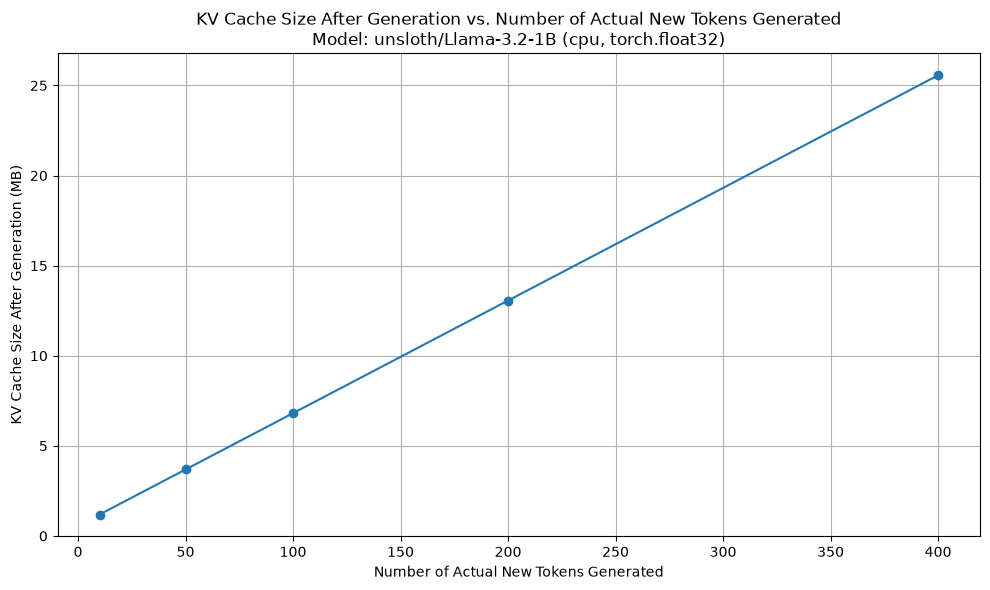


Exercise Complete.


In [5]:
print("\n--- Results Summary ---")
print("Max New Tokens | Actual New Tokens | Peak Memory (MB) during Gen | Time (s)")
print("---------------|-------------------|-----------------------------|----------")
for i, requested_length in enumerate(generation_lengths):
    if i < len(peak_memory_results_mb) and i < len(actual_tokens_generated_list) and i < len(generation_times):
        actual_len = actual_tokens_generated_list[i]
        mem_val = peak_memory_results_mb[i]
        time_val = generation_times[i]
        print(f"{requested_length:15} | {actual_len:17} | {mem_val:27.2f} | {time_val:8.4f}")
    else:
        # This case handles if a generation run failed and wasn't recorded
        print(f"{requested_length:15} | {'N/A':17} | {'N/A':27} | {'N/A':8}")

# ---------------------------------------------------------------------------
# 1. Trend Analysis
# ---------------------------------------------------------------------------
valid = [(t, m) for t, m in zip(actual_tokens_generated_list, peak_memory_results_mb)
         if t > 0 and m == m]  # m == m filters NaN
if len(valid) >= 2:
    growth = [(m - initial_peak_memory_mb) for _, m in valid]
    print("\n1. Trend analysis")
    print("   Memory above the loaded model (MB) for each run:",
          ", ".join(f"{t} tok -> {g:.2f} MB" for (t, _), g in zip(valid, growth)))
    # Linear fit  memory = a * tokens + b
    import numpy as np
    xs = np.array([t for t, _ in valid], dtype=float)
    ys = np.array([m for _, m in valid], dtype=float)
    a, b = np.polyfit(xs, ys, 1)
    r2 = 1 - ((ys - (a * xs + b)) ** 2).sum() / ((ys - ys.mean()) ** 2).sum()
    print(f"   Linear fit: memory ≈ {a:.4f} MB/token * tokens + {b:.2f} MB   (R² = {r2:.4f})")
    print("   -> The growth is essentially LINEAR in the number of generated tokens: each new token appends"
          " one K and one V vector per layer to the cache, so the footprint grows by a constant amount per token.")

    # -----------------------------------------------------------------------
    # 2. Estimate memory per token from two data points
    # -----------------------------------------------------------------------
    (t_short, m_short), (t_long, m_long) = valid[1], valid[-1]
    delta_mem = m_long - m_short
    delta_tok = t_long - t_short
    mem_per_token_mb = delta_mem / delta_tok if delta_tok > 0 else float('nan')
    print("\n2. Memory per generated token")
    print(f"   Chosen points: {t_short} tokens -> {m_short:.2f} MB  and  {t_long} tokens -> {m_long:.2f} MB")
    print(f"   ΔMemory = {delta_mem:.2f} MB, ΔTokens = {delta_tok}  =>  ≈ {mem_per_token_mb:.4f} MB/token "
          f"({mem_per_token_mb*1024:.1f} KB/token)")

    # Theoretical KV-cache cost per token for this model (2 * layers * kv_heads * head_dim * bytes)
    cfg = model.config
    n_kv = getattr(cfg, "num_key_value_heads", cfg.num_attention_heads)
    head_dim = getattr(cfg, "head_dim", None) or cfg.hidden_size // cfg.num_attention_heads
    bytes_per = torch.tensor([], dtype=dtype).element_size()
    theo_kb = 2 * cfg.num_hidden_layers * n_kv * head_dim * bytes_per / 1024
    print(f"   Theoretical KV cache per token for this config: 2 x {cfg.num_hidden_layers} layers x {n_kv} kv-heads x "
          f"{head_dim} head_dim x {bytes_per} B = {theo_kb:.1f} KB/token")
    print("   (On CUDA the measured peak also includes transient activations/logits, so it is slightly above the theoretical value.)")

    # -----------------------------------------------------------------------
    # 3. Practical impact
    # -----------------------------------------------------------------------
    print("\n3. Practical impact")
    print("   Because the cache grows linearly with sequence length (and multiplies with batch size), it eventually"
          " dominates GPU memory: at the per-token cost above, a 128k-token context for a single sequence would need "
          f"~{theo_kb*128*1024/1024/1024:.1f} GB just for the KV cache, on top of the weights. In practice the usable"
          " context window is therefore bounded by VRAM (and by how many concurrent requests share it), not by the"
          " model's theoretical max_position_embeddings. This is why GQA/MQA, KV-cache quantization, paged attention"
          " (vLLM) and sliding-window attention exist — they all attack this linear term.")
else:
    print("Not enough valid data points for the analysis.")

# --- Plotting ---
valid_indices = [i for i, mem in enumerate(peak_memory_results_mb)
                 if isinstance(mem, (int, float)) and mem == mem and actual_tokens_generated_list[i] > 0]
plot_lengths = [actual_tokens_generated_list[i] for i in valid_indices]
plot_memory = [peak_memory_results_mb[i] for i in valid_indices]

if plot_lengths and plot_memory and len(plot_lengths) == len(plot_memory):
    try:
        plt.figure(figsize=(10, 6))
        plt.plot(plot_lengths, plot_memory, marker='o', linestyle='-')
        ylabel = 'Peak GPU Memory Allocated During Generation (MB)' if device == "cuda" else 'KV Cache Size After Generation (MB)'
        plt.title(f'{ylabel.split(" (")[0]} vs. Number of Actual New Tokens Generated\nModel: {model_name} ({device}, {dtype})')
        plt.xlabel('Number of Actual New Tokens Generated')
        plt.ylabel(ylabel)
        plt.grid(True)
        plt.tight_layout()
        plot_filename = "kv_cache_memory_growth.png"
        plt.savefig(plot_filename)
        print(f"\nPlot saved to {plot_filename}")
        plt.show()
    except Exception as e:
        print(f"Could not generate plot: {e}. Ensure matplotlib is installed.")
else:
    print("Not enough valid data points to plot.")

print("\nExercise Complete.")
